In [36]:
import os
import pandas as pd
import numpy as np

from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression

#import datetime
#import json

import matplotlib.pyplot as plt
%matplotlib inline
#%timeit

In [37]:
#--- Folders and Directories
data_folder = r"..\data\afterstudy"
test_data = r"..\data"
output_folder = r"..\data\outputs"

OBS_2015_csv = r"Final 2015 Onboard Transit Passenger Survey.xlsx"
OBS_2023 = r"od_20240422_sandagca_weighted_combined_draftfinal_noPII.xlsx"
sheet_data = r"OD_RESULTS"

MTS_APC_file = r"request_20240418_mts_normalized_apc_stoplist.xlsx"
sheet_APC = r"NORMALIZED_APC"
sheet_farebox = r"FAREBOX_ROUTES"

NCTD_APC_file = r"request_20240507_sandag_NCTD_projectmaterials.xlsx"
sheet_NCTD_APC = r"APC"

In [38]:
srvy_filename = 'survey.csv'
unique_wts_filename = 'unique_weight_id.csv'
targets_filesname = 'obs_targets.csv'
importance_vect_filename = 'importance_vect.csv'
incidence_matrix_filename = 'incidence_mat.csv'

In [39]:
X = pd.read_csv(os.path.join(output_folder, incidence_matrix_filename)).T
cols_as_wts_name = pd.read_csv(os.path.join(output_folder, unique_wts_filename))

y = pd.read_csv(os.path.join(output_folder, targets_filesname))

In [40]:
print(X.shape)
print(cols_as_wts_name.shape)
print(y.shape)

(2398, 5900)
(5900, 1)
(2398, 2)


In [42]:
rename_cols = cols_as_wts_name.to_dict()['unique_weight_id']
X = X.rename(columns=rename_cols)
X

,101_00_AM,101_00_EVE,101_00_MIDDAY,101_00_PM,101_01_AM,101_01_EVE,101_01_MIDDAY,101_01_PM,105_00_AM,105_00_EVE,105_00_MIDDAY,105_00_PM,105_01_AM,105_01_EVE,105_01_MIDDAY,105_01_PM,10_00_AM,10_00_EVE,10_00_MIDDAY,10_00_PM,10_01_AM,10_01_EVE,10_01_MIDDAY,10_01_PM,110_00_PM,110_01_AM,115_00_AM,115_00_EVE,115_00_MIDDAY,115_00_PM,115_01_AM,115_01_EVE,115_01_MIDDAY,115_01_PM,11_00_AM,11_00_EVE,11_00_MIDDAY,11_00_PM,11_01_AM,11_01_EVE,11_01_MIDDAY,11_01_PM,120_00_AM,120_00_EVE,120_00_MIDDAY,120_00_PM,120_01_AM,120_01_EVE,120_01_MIDDAY,120_01_PM,12_00_AM,12_00_EVE,12_00_MIDDAY,12_00_PM,12_01_AM,12_01_EVE,12_01_MIDDAY,12_01_PM,13_00_AM,13_00_EVE,...,Orange_01_PM_75039_75041,Orange_01_PM_75039_75066,Orange_01_PM_75039_75068,Orange_01_PM_75039_75072,Orange_01_PM_75039_75087,Orange_01_PM_75039_75088,Orange_01_PM_75039_75090,Orange_01_PM_75039_75102,Orange_01_PM_75040_00000,Orange_01_PM_75041_75066,Orange_01_PM_75041_75072,Orange_01_PM_75041_75102,Orange_01_PM_75066_75068,Orange_01_PM_75066_75071,Orange_01_PM_75066_75075,Orange_01_PM_75066_75088,Orange_01_PM_75066_75090,Orange_01_PM_75066_75092,Orange_01_PM_75066_75102,Orange_01_PM_75066_75109,Orange_01_PM_75068_75072,Orange_01_PM_75068_75075,Orange_01_PM_75068_75087,Orange_01_PM_75068_75088,Orange_01_PM_75068_75090,Orange_01_PM_75068_75092,Orange_01_PM_75068_75102,Orange_01_PM_75068_75109,Orange_01_PM_75071_75088,Orange_01_PM_75071_75092,Orange_01_PM_75071_75102,Orange_01_PM_75071_75109,Orange_01_PM_75072_75087,Orange_01_PM_75072_75088,Orange_01_PM_75072_75090,Orange_01_PM_75072_75092,Orange_01_PM_75072_75102,Orange_01_PM_75075_75087,Orange_01_PM_75075_75088,Orange_01_PM_75075_75090,Orange_01_PM_75075_75092,Orange_01_PM_75075_75102,Orange_01_PM_75087_75109,Orange_01_PM_75088_75109,Orange_01_PM_75089_00000,Orange_01_PM_75090_75087,Orange_01_PM_75090_75109,Orange_01_PM_75092_75087,Orange_01_PM_75092_75088,Orange_01_PM_75092_75090,Orange_01_PM_75092_75109,Orange_01_PM_75102_75087,Orange_01_PM_75102_75088,Orange_01_PM_75102_75090,Orange_01_PM_75102_75092,Orange_01_PM_75102_75109,Orange_01_PM_99887_75039,Orange_01_PM_99887_75066,Orange_01_PM_99887_75072,Orange_01_PM_99887_75075
101_00_AM,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
101_00_EVE,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
101_00_MIDDAY,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
101_00_PM,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
101_01_AM,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Orange_01_PM_75102_Offs,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [43]:
lin = Lasso(alpha=0.0001, precompute=True, max_iter=1000,
            positive=True, random_state=9999, selection='random',
            fit_intercept = False
           )
model = lin.fit(X,y['targets'])

In [44]:
lin_model = LinearRegression(fit_intercept=False, n_jobs=-1, positive=True).fit(X,y['targets'])
lin_y_hat = lin_model.predict(X)

In [45]:
y_hat = model.predict(X)

In [46]:
y_hat

array([2.09390200e+02, 1.36150200e+02, 4.83390200e+02, ...,
       1.36425515e+02, 2.28575535e-01, 3.48572905e-01])

In [88]:
def get_comparison_plot_subtrgts(y, y_hat):
    """
    """
    
    def subplot_ax(ax, x, y, limit=False, title=None):
        ax.scatter(x, y, alpha=0.6, c='g')
        #plt.
        ax.tick_params(axis='both', length=0)
        ax.set_xlabel("Observed Targets")
        ax.set_ylabel("Estimated Targets")
        #axes[0].suptitle("Estimated vs Observed Line Boardings by Direction by Time Period", fontsize=12)
        if title==None:
            ax.set_title("Re-estimated Survey Weights", fontsize=10)
        else:
            ax.set_title(title, fontsize=10)

        lims = [
            np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
            np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
        ]

        # now plot both limits against eachother
        ax.plot(lims, lims, 'r-', alpha=0.5, zorder=0)
        
        if limit:
            ax.set_xlim(0, 100)
            ax.set_ylim(0, 100)
        
    plt.rcParams['figure.figsize'] = [21, 6]
    fig, axes = plt.subplots(1, 2)
    
    subplot_ax(axes[0], y, y_hat, limit=True)
    subplot_ax(axes[1], y, y_hat,)
    #subplot_ax(axes[2], tempx, tempy, limit=True, title="Line Boarding Targets")
    #subplot_ax(axes[3], tempx, tempy, title="Line Boarding Targets")


    plt.show()

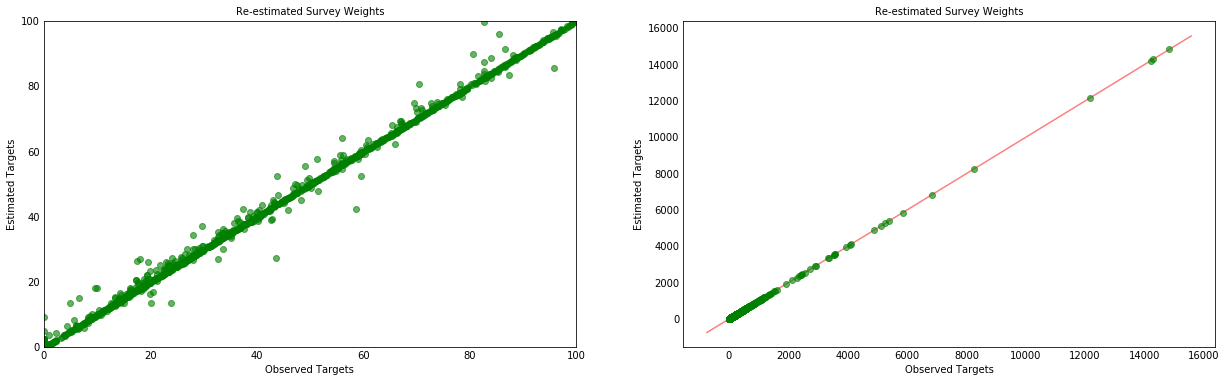

In [89]:
get_comparison_plot_subtrgts(y['targets'], y_hat)

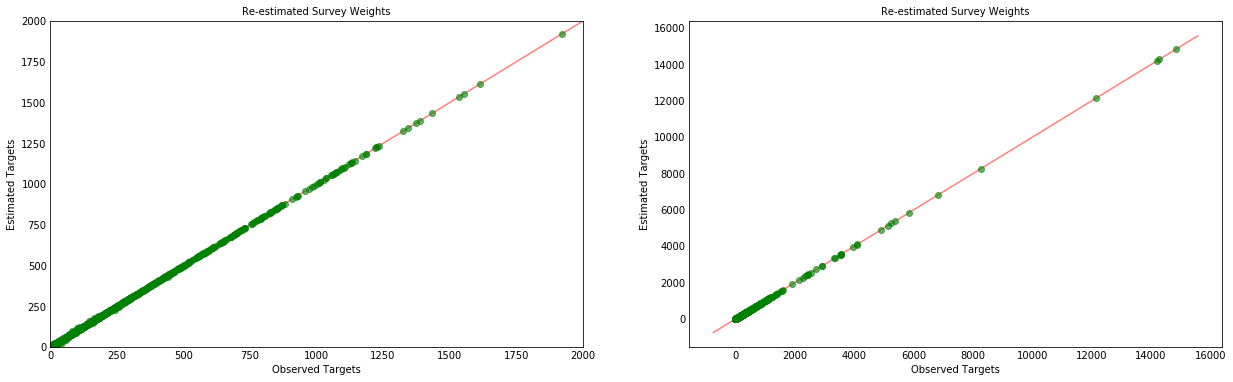

In [49]:
get_comparison_plot_subtrgts(y['targets'], lin_y_hat)

In [50]:
np.where(lin_model.coef_==0, 1, 0).sum()

3587

In [51]:
np.where(model.coef_==0, 1, 0).sum()

1323

In [52]:
cols_as_wts_name['wts'] = model.coef_
cols_as_wts_name['line'] = cols_as_wts_name['unique_weight_id'].str.count('_').astype('int')
# y_line = cols_as_wts_name['line']
# cols_as_wts_name = pd.merge(cols_as_wts_name, y, how='left', left_on = 'unique_weight_id', right_on = 'key')
# cols_as_wts_name

In [53]:
zero_coeffs = cols_as_wts_name.loc[cols_as_wts_name['wts']==0].copy()
zero_coeffs['onStat'] = zero_coeffs['unique_weight_id'].str.split("_", expand=True)[3]
zero_coeffs['offStat'] = zero_coeffs['unique_weight_id'].str.split("_", expand=True)[4]
zero_coeffs

,unique_weight_id,wts,line,onStat,offStat
384,398_00_AM_28006_28003,0.0,4,28006,28003
395,398_00_EVE_28005_28002,0.0,4,28005,28002
398,398_00_EVE_28007_28001,0.0,4,28007,28001
399,398_00_EVE_28007_28002,0.0,4,28007,28002
400,398_00_EVE_28007_28003,0.0,4,28007,28003
...,...,...,...,...,...
5880,Orange_01_PM_75075_75092,0.0,4,75075,75092
5884,Orange_01_PM_75089_00000,0.0,4,75089,00000
5887,Orange_01_PM_75092_75087,0.0,4,75092,75087
5898,Orange_01_PM_99887_75072,0.0,4,99887,75072


In [54]:
zero_coeffs['onStat'].nunique()
zero_coeffs['offStat'].nunique()

123

### Average Multiple Optimization Runs to Reduce Zero Weights

Apply a min value on weights?

In [55]:
def lasso(X, y, r_state = 9999, **kwgs):
    lin = Lasso(alpha=0.0001, precompute=True, max_iter=1000,
            positive=True, random_state=r_state, selection='random',
            fit_intercept = False
           )
    model = lin.fit(X,y)
    y_hat = model.predict(X)
    
    return (y_hat, model.coef_)

In [56]:
np.random.seed(333)
seeds = np.random.randint(10, 10000, size=10)
model_set = []
coeffs = []
for seed in seeds:
    test_lasso = lasso(X, y['targets'], r_state=seed)
    model_set.append(test_lasso)
    coeffs.append(test_lasso[1]) 
    print(np.where(test_lasso[1]==0, 1, 0).sum())

1164
1333
1359
1531
1301
1415
1389
1384
1340
1464


In [57]:
avg_coeffs = np.mean(coeffs, axis=0)
min(avg_coeffs[np.nonzero(avg_coeffs)])

1.7679117429262685e-12

In [58]:
avg_coeffs[np.argwhere(avg_coeffs<0.1)].sum()

6.643450221594371

In [59]:
np.where(avg_coeffs==0, 1, 0).sum()

298

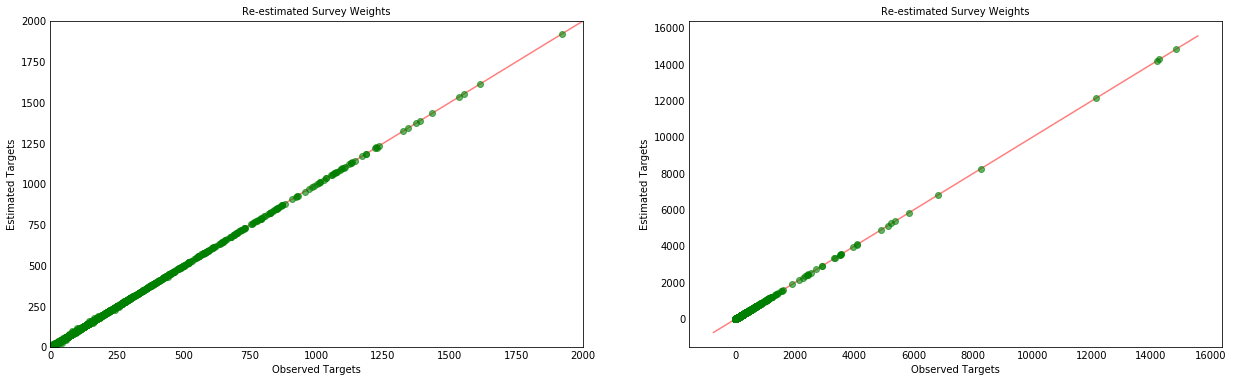

In [60]:
model_y_hats = [one_set[0] for one_set in model_set ]
avg_y_hats = np.mean(model_y_hats, axis=0)
get_comparison_plot_subtrgts(y['targets'], avg_y_hats)

In [61]:
A = X @ avg_coeffs

(array([5.693e+03, 1.300e+02, 5.200e+01, 1.300e+01, 7.000e+00, 2.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 2.000e+00]),
 array([   0.        ,  241.25505226,  482.51010452,  723.76515677,
         965.02020903, 1206.27526129, 1447.53031355, 1688.78536581,
        1930.04041806, 2171.29547032, 2412.55052258]),
 <a list of 10 Patch objects>)

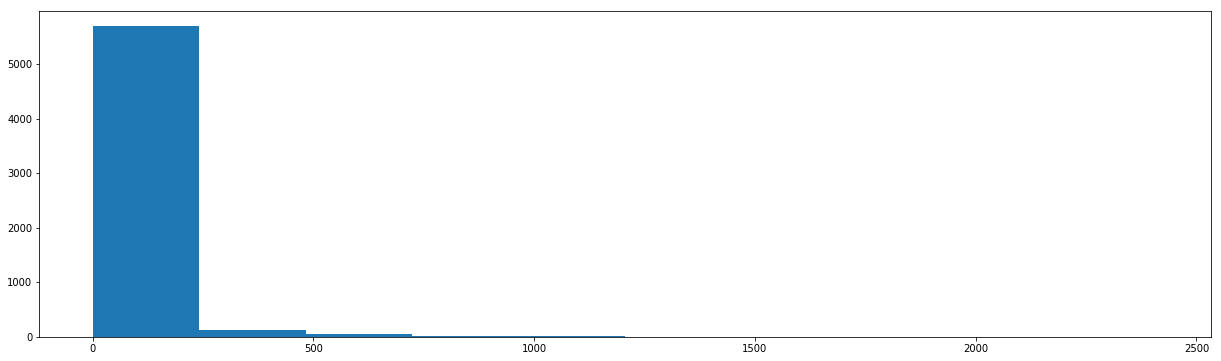

In [62]:
plt.hist(avg_coeffs, bins=10, range=(0, avg_coeffs.max()))

(0, 500)

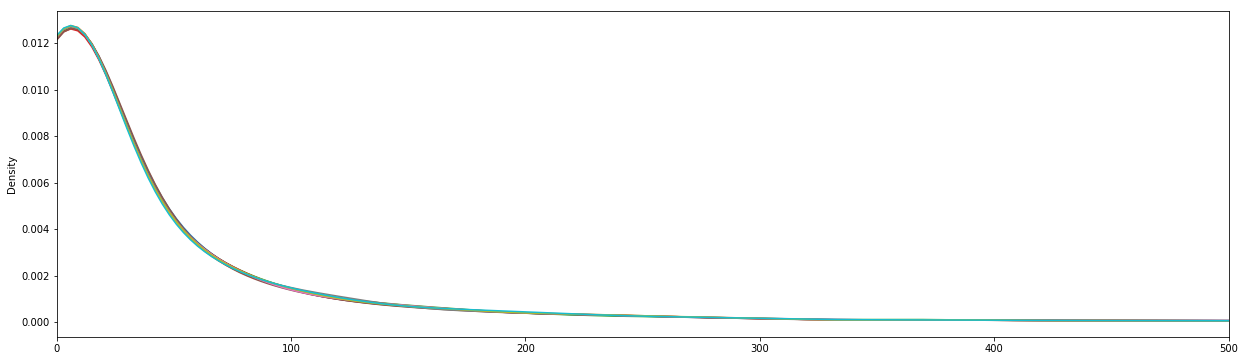

In [63]:
fig, ax = plt.subplots(1,1)
for coeff in coeffs:
    ax = pd.Series(coeff).plot.kde(ind=np.linspace(0, 3000, 1000))

ax.set_xlim(0, 500)
#ax.set_ylim(0, 2000)

### Compare 2015 Weights with Run 3 Weights

In [67]:
# Run3 to Survey assignment
MIN_VALUE = 0.2


survey_df = pd.read_csv(os.path.join(output_folder, srvy_filename))

#Coeff df
coeffs = pd.DataFrame({'unique_weight_id': X.columns,
                      'run3RawWts': avg_coeffs}
                     )


coeffs['run3RawWts'] = np.where(coeffs['run3RawWts']<MIN_VALUE, MIN_VALUE, coeffs['run3RawWts'])

# Distribute survey group wt to survey entries
survey_df = pd.merge(survey_df, coeffs, how='left', on='unique_weight_id')
survey_df['count'] = survey_df.groupby('unique_weight_id')['ID'].transform(lambda x: x.count())
survey_df['run3Wts'] = survey_df['run3RawWts']/survey_df['count']

# 'line_srvy' ==2 for line targets, ==4 for rail targets
survey_df['line_srvy'] = survey_df['unique_weight_id'].str.count('_')

# Rescale for line targets
survey_df['sum_wts_2015'] = (
    survey_df[survey_df['line_srvy']==2]
    .groupby('unique_weight_id')['UNLINKED_WGHT_FCTR']
    .transform(lambda x: x.sum())
)

survey_df.loc[survey_df['line_srvy']==2, 'rescaled_wts'] = survey_df['UNLINKED_WGHT_FCTR'] * survey_df['run3RawWts'] / survey_df['sum_wts_2015']
survey_df


,Unnamed: 0,ID,ROUTE_DIRECTION[Code],ROUTE_DIRECTION,DIRECTION,TIME_PERIOD,UNLINKED_WGHT_FCTR,BOARDING_ID,ALIGHTING_ID,UID,subkey1,subkey2,subkey2_Ons,subkey2_Offs,unique_weight_id,run3RawWts,count,run3Wts,line_srvy,sum_wts_2015,rescaled_wts
0,0,31664,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,6.102785,21626,24944,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,6.095804
1,1,22945,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,31.047752,24944,21491,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,31.012236
2,2,31637,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,6.102785,95035,24944,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,6.095804
3,3,31644,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,31.047752,95035,24954,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,31.012236
4,4,31649,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,6.102785,21399,21626,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,6.095804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35255,35255,72594,MTS_1_Orange_01,MTS - Orange - El Cajon - Courthouse (Westbound),1,EVE,5.687218,75090,75109,Orange_01_EVE_75090_75109,Orange_01_EVE,Orange_01_EVE_75090_75109,Orange_01_EVE_75090,Orange_01_EVE_75109,Orange_01_EVE_75090_75109,8.824870,2,4.412435,4,NaN,NaN
35256,35256,72927,MTS_1_Orange_01,MTS - Orange - El Cajon - Courthouse (Westbound),1,EVE,5.687218,75088,75109,Orange_01_EVE_75088_75109,Orange_01_EVE,Orange_01_EVE_75088_75109,Orange_01_EVE_75088,Orange_01_EVE_75109,Orange_01_EVE_75088_75109,10.514013,4,2.628503,4,NaN,NaN
35257,35257,72929,MTS_1_Orange_01,MTS - Orange - El Cajon - Courthouse (Westbound),1,EVE,5.687218,75088,75109,Orange_01_EVE_75088_75109,Orange_01_EVE,Orange_01_EVE_75088_75109,Orange_01_EVE_75088,Orange_01_EVE_75109,Orange_01_EVE_75088_75109,10.514013,4,2.628503,4,NaN,NaN
35258,35258,72930,MTS_1_Orange_01,MTS - Orange - El Cajon - Courthouse (Westbound),1,EVE,5.687218,75088,75087,Orange_01_EVE_75088_75087,Orange_01_EVE,Orange_01_EVE_75088_75087,Orange_01_EVE_75088,Orange_01_EVE_75087,Orange_01_EVE_75088_75087,15.220700,1,15.220700,4,NaN,NaN


In [64]:
# Run3 to Survey assignment
MIN_VALUE = 0.2


survey_df = pd.read_csv(os.path.join(output_folder, srvy_filename))

#Coeff df
coeffs = pd.DataFrame({'unique_weight_id': X.columns,
                      'run3RawWts': avg_coeffs}
                     )

coeffs.to_excel(os.path.join(output_folder, "checks", "original_weights_unprocessed_new.xlsx"), index=False)

In [68]:
# QC that rescaled wts work
Wts_2015 = survey_df.loc[survey_df['line_srvy']==2, ['unique_weight_id', 'UNLINKED_WGHT_FCTR', 'run3Wts', 'rescaled_wts']].groupby('unique_weight_id').agg('sum')
Wts_2015

,UNLINKED_WGHT_FCTR,run3Wts,rescaled_wts
unique_weight_id,,,
101_00_AM,209.630000,209.390200,209.390200
101_00_EVE,136.390000,136.150200,136.150200
101_00_MIDDAY,483.630000,483.390200,483.390200
101_00_PM,244.690000,244.450200,244.450200
101_01_AM,177.850000,177.610200,177.610200
...,...,...,...
9_00_PM,79.384746,79.144946,79.144946
9_01_AM,35.292662,35.052862,35.052862
9_01_EVE,32.758127,32.518327,32.518327


In [69]:
survey_df['rescaled_wts'] = survey_df['rescaled_wts'].fillna(0)

In [70]:
print(survey_df.loc[survey_df['line_srvy']!=2, 'run3Wts'].sum())
print(survey_df.loc[survey_df['line_srvy']!=2, 'run3RawWts'].sum())

139968.80271077936
1071890.0357573042


In [71]:
survey_df['count'].describe()

count    35260.000000
mean        37.487635
std         42.086378
min          1.000000
25%          5.000000
50%         22.000000
75%         57.000000
max        251.000000
Name: count, dtype: float64

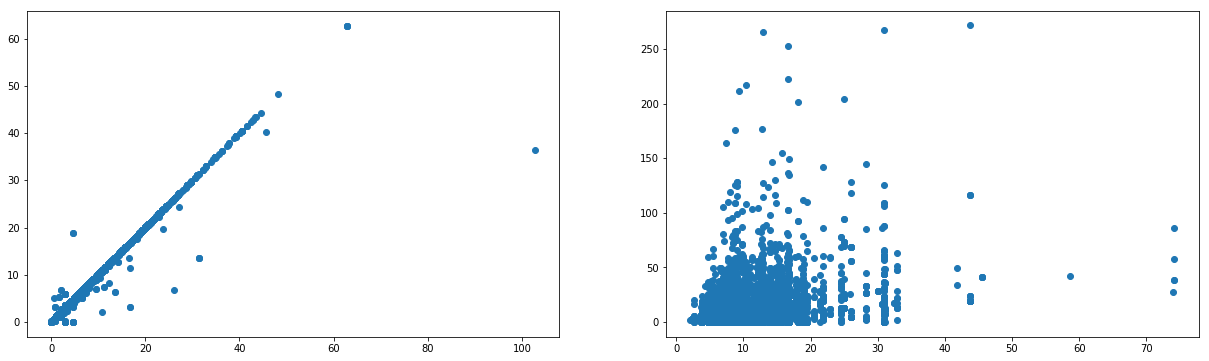

In [72]:
X_line_2015_wts = survey_df.loc[survey_df['line_srvy']==2, 'UNLINKED_WGHT_FCTR']
Y_line_2015_wts = survey_df.loc[survey_df['line_srvy']==2, 'rescaled_wts']

X_rail_2015_wts = survey_df.loc[survey_df['line_srvy']!=2, 'UNLINKED_WGHT_FCTR']
Y_rail_2015_wts = survey_df.loc[survey_df['line_srvy']!=2, 'run3Wts']

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(X_line_2015_wts, Y_line_2015_wts)
ax2.scatter(X_rail_2015_wts, Y_rail_2015_wts)

### Rescale Rail Wts by Ons

In [73]:
survey_df['sum_rail_2015'] = (
    survey_df[survey_df['subkey2_Ons'].notna()]
    .groupby('subkey2_Ons')['UNLINKED_WGHT_FCTR']
    .transform(lambda x: x.sum())
)

survey_df.loc[survey_df['subkey2_Ons'].notna(), 'rescaled_rail_wts'] = survey_df['UNLINKED_WGHT_FCTR'] * survey_df['run3Wts'] / survey_df['sum_rail_2015']
survey_df

,Unnamed: 0,ID,ROUTE_DIRECTION[Code],ROUTE_DIRECTION,DIRECTION,TIME_PERIOD,UNLINKED_WGHT_FCTR,BOARDING_ID,ALIGHTING_ID,UID,subkey1,subkey2,subkey2_Ons,subkey2_Offs,unique_weight_id,run3RawWts,count,run3Wts,line_srvy,sum_wts_2015,rescaled_wts,sum_rail_2015,rescaled_rail_wts
0,0,31664,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,6.102785,21626,24944,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,6.095804,NaN,NaN
1,1,22945,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,31.047752,24944,21491,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,31.012236,NaN,NaN
2,2,31637,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,6.102785,95035,24944,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,6.095804,NaN,NaN
3,3,31644,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,31.047752,95035,24954,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,31.012236,NaN,NaN
4,4,31649,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,6.102785,21399,21626,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,6.095804,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35255,35255,72594,MTS_1_Orange_01,MTS - Orange - El Cajon - Courthouse (Westbound),1,EVE,5.687218,75090,75109,Orange_01_EVE_75090_75109,Orange_01_EVE,Orange_01_EVE_75090_75109,Orange_01_EVE_75090,Orange_01_EVE_75109,Orange_01_EVE_75090_75109,8.824870,2,4.412435,4,NaN,0.000000,39.810527,0.630348
35256,35256,72927,MTS_1_Orange_01,MTS - Orange - El Cajon - Courthouse (Westbound),1,EVE,5.687218,75088,75109,Orange_01_EVE_75088_75109,Orange_01_EVE,Orange_01_EVE_75088_75109,Orange_01_EVE_75088,Orange_01_EVE_75109,Orange_01_EVE_75088_75109,10.514013,4,2.628503,4,NaN,0.000000,28.436091,0.525701
35257,35257,72929,MTS_1_Orange_01,MTS - Orange - El Cajon - Courthouse (Westbound),1,EVE,5.687218,75088,75109,Orange_01_EVE_75088_75109,Orange_01_EVE,Orange_01_EVE_75088_75109,Orange_01_EVE_75088,Orange_01_EVE_75109,Orange_01_EVE_75088_75109,10.514013,4,2.628503,4,NaN,0.000000,28.436091,0.525701
35258,35258,72930,MTS_1_Orange_01,MTS - Orange - El Cajon - Courthouse (Westbound),1,EVE,5.687218,75088,75087,Orange_01_EVE_75088_75087,Orange_01_EVE,Orange_01_EVE_75088_75087,Orange_01_EVE_75088,Orange_01_EVE_75087,Orange_01_EVE_75088_75087,15.220700,1,15.220700,4,NaN,0.000000,28.436091,3.044140


In [74]:
survey_df.loc[survey_df['subkey2_Ons'].notna(), 'rescaled_rail_wts'].sum()

9111.068647846341

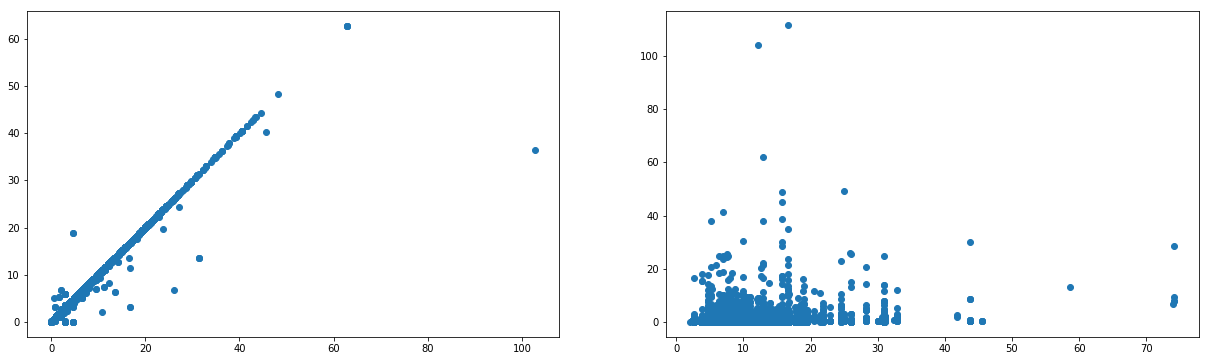

In [75]:
X_line_2015_wts = survey_df.loc[survey_df['line_srvy']==2, 'UNLINKED_WGHT_FCTR']
Y_line_2015_wts = survey_df.loc[survey_df['line_srvy']==2, 'rescaled_wts']

X_rail_2015_wts = survey_df.loc[survey_df['line_srvy']!=2, 'UNLINKED_WGHT_FCTR']
Y_rail_2015_wts = survey_df.loc[survey_df['line_srvy']!=2, 'rescaled_rail_wts']

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(X_line_2015_wts, Y_line_2015_wts)
ax2.scatter(X_rail_2015_wts, Y_rail_2015_wts)

In [76]:
survey_df['sum_rail_offs_2015'] = (
    survey_df[survey_df['subkey2_Offs'].notna()]
    .groupby('subkey2_Offs')['UNLINKED_WGHT_FCTR']
    .transform(lambda x: x.sum())
)

survey_df.loc[survey_df['subkey2_Offs'].notna(), 'rescaled_rail_off_wts'] = survey_df['UNLINKED_WGHT_FCTR'] * survey_df['rescaled_rail_wts'] / survey_df['sum_rail_offs_2015']
survey_df

,Unnamed: 0,ID,ROUTE_DIRECTION[Code],ROUTE_DIRECTION,DIRECTION,TIME_PERIOD,UNLINKED_WGHT_FCTR,BOARDING_ID,ALIGHTING_ID,UID,subkey1,subkey2,subkey2_Ons,subkey2_Offs,unique_weight_id,run3RawWts,count,run3Wts,line_srvy,sum_wts_2015,rescaled_wts,sum_rail_2015,rescaled_rail_wts,sum_rail_offs_2015,rescaled_rail_off_wts
0,0,31664,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,6.102785,21626,24944,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,6.095804,NaN,NaN,NaN,NaN
1,1,22945,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,31.047752,24944,21491,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,31.012236,NaN,NaN,NaN,NaN
2,2,31637,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,6.102785,95035,24944,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,6.095804,NaN,NaN,NaN,NaN
3,3,31644,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,31.047752,95035,24954,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,31.012236,NaN,NaN,NaN,NaN
4,4,31649,NCT_2_101_00,NCTD 101 Oceanside - UTC/VA/UCSD [North],0,AM,6.102785,21399,21626,101_00_AM,101_00_AM,NaN,NaN,NaN,101_00_AM,209.390200,18,11.632789,2,209.63,6.095804,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35255,35255,72594,MTS_1_Orange_01,MTS - Orange - El Cajon - Courthouse (Westbound),1,EVE,5.687218,75090,75109,Orange_01_EVE_75090_75109,Orange_01_EVE,Orange_01_EVE_75090_75109,Orange_01_EVE_75090,Orange_01_EVE_75109,Orange_01_EVE_75090_75109,8.824870,2,4.412435,4,NaN,0.000000,39.810527,0.630348,125.118800,0.028652
35256,35256,72927,MTS_1_Orange_01,MTS - Orange - El Cajon - Courthouse (Westbound),1,EVE,5.687218,75088,75109,Orange_01_EVE_75088_75109,Orange_01_EVE,Orange_01_EVE_75088_75109,Orange_01_EVE_75088,Orange_01_EVE_75109,Orange_01_EVE_75088_75109,10.514013,4,2.628503,4,NaN,0.000000,28.436091,0.525701,125.118800,0.023895
35257,35257,72929,MTS_1_Orange_01,MTS - Orange - El Cajon - Courthouse (Westbound),1,EVE,5.687218,75088,75109,Orange_01_EVE_75088_75109,Orange_01_EVE,Orange_01_EVE_75088_75109,Orange_01_EVE_75088,Orange_01_EVE_75109,Orange_01_EVE_75088_75109,10.514013,4,2.628503,4,NaN,0.000000,28.436091,0.525701,125.118800,0.023895
35258,35258,72930,MTS_1_Orange_01,MTS - Orange - El Cajon - Courthouse (Westbound),1,EVE,5.687218,75088,75087,Orange_01_EVE_75088_75087,Orange_01_EVE,Orange_01_EVE_75088_75087,Orange_01_EVE_75088,Orange_01_EVE_75087,Orange_01_EVE_75088_75087,15.220700,1,15.220700,4,NaN,0.000000,28.436091,3.044140,85.308272,0.202943


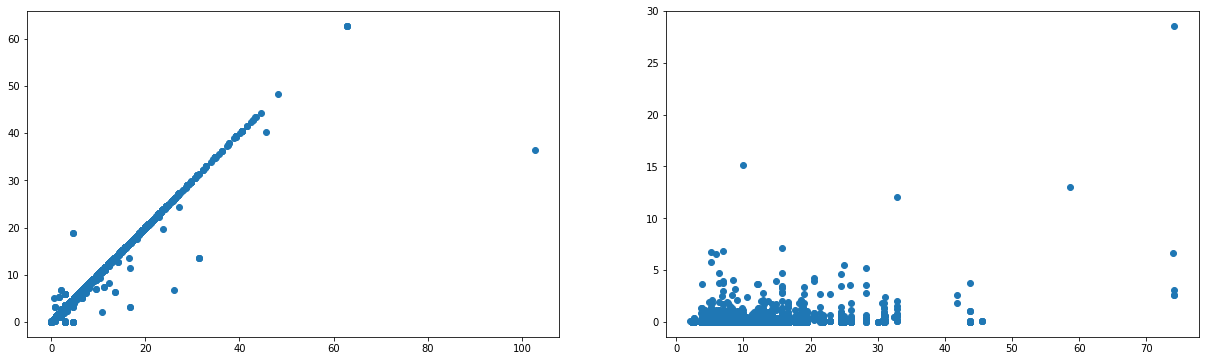

In [77]:
X_line_2015_wts = survey_df.loc[survey_df['line_srvy']==2, 'UNLINKED_WGHT_FCTR']
Y_line_2015_wts = survey_df.loc[survey_df['line_srvy']==2, 'rescaled_wts']

X_rail_2015_wts = survey_df.loc[survey_df['line_srvy']!=2, 'UNLINKED_WGHT_FCTR']
Y_rail_2015_wts = survey_df.loc[survey_df['line_srvy']!=2, 'rescaled_rail_off_wts']

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(X_line_2015_wts, Y_line_2015_wts)
ax2.scatter(X_rail_2015_wts, Y_rail_2015_wts)

### Run3 Wts No Scaling for Rail Wts

In [78]:
# survey_df['rescaled_run3_wts'] = survey_df.loc[survey_df['line_srvy']==2, 'rescaled_wts']
# survey_df['rescaled_run3_wts'] = survey_df.loc[survey_df['line_srvy']!=2, 'run3Wts']

survey_df['rescaled_run3_wts'] = 0
survey_df.loc[survey_df['line_srvy']==2,'rescaled_run3_wts'] = survey_df['rescaled_wts']
survey_df.loc[survey_df['line_srvy']!=2,'rescaled_run3_wts'] = survey_df['run3Wts']

In [79]:
survey_df['rescaled_run3_wts'].sum()

280605.804192621

In [80]:
survey_raw_file = os.path.join(data_folder, OBS_2023)

all_srvy = pd.read_excel(survey_raw_file)

srvy_wRewts = pd.merge(left = all_srvy, right = survey_df[['ID', 'rescaled_run3_wts']],
                       how='left',
                       on='ID'
                      )
srvy_wRewts = srvy_wRewts.rename(columns={'rescaled_run3_wts': 'REWEIGHTED_UNLINKED'})
srvy_wRewts['REWEIGHTED_UNLINKED'] = srvy_wRewts['REWEIGHTED_UNLINKED'].fillna(0)
srvy_wRewts['REWEIGHTED_LINKED'] = srvy_wRewts['REWEIGHTED_UNLINKED'] * srvy_wRewts['LINKED_MULTP']

In [81]:
# srvy_wRewts.to_excel(os.path.join(output_folder, "Reweighted2023OnboardSurvey_2024-05-24.xlsx"), index=False)

In [82]:
skinny_Run2_rescaked_wts_columns = ['ID', 'ROUTE_DIRECTION[Code]', 'ROUTE_DIRECTION',
                                    'TIME_PERIOD', 'UNLINKED_WGHT_FCTR', 'LINKED_WGHT_FCTR',
                                    'REWEIGHTED_LINKED', 'REWEIGHTED_UNLINKED'
                                   ]

srvy_wRewts[skinny_Run2_rescaked_wts_columns].to_excel(os.path.join(output_folder, "2023OBS_ReWeighted_2024-05-24.xlsx"), index=False)

In [83]:
survey_df.columns

Index(['Unnamed: 0', 'ID', 'ROUTE_DIRECTION[Code]', 'ROUTE_DIRECTION',
       'DIRECTION', 'TIME_PERIOD', 'UNLINKED_WGHT_FCTR', 'BOARDING_ID',
       'ALIGHTING_ID', 'UID', 'subkey1', 'subkey2', 'subkey2_Ons',
       'subkey2_Offs', 'unique_weight_id', 'run3RawWts', 'count', 'run3Wts',
       'line_srvy', 'sum_wts_2015', 'rescaled_wts', 'sum_rail_2015',
       'rescaled_rail_wts', 'sum_rail_offs_2015', 'rescaled_rail_off_wts',
       'rescaled_run3_wts'],
      dtype='object')

In [84]:
survey_df.to_csv(os.path.join(output_folder, 'survey_df_forcheck_2024-05-24.csv'), index = False)